# Lab Instructions

You have been hired by a record executive to design a guaranteed smash hit song based on data.  The exec has decided that if you make a song that has all the most popular features of recent songs then it will definitely be a hit.  So if - for example - the most common key in the Spotify data is C# then we would want the song we are designing to also be in C#.  If a "typical" value of BPM is between 120 and 130 then we would want the song we are designing to also have a tempo between 120 and 130 BMP.

Visualize and describe the distribution of:
* BPM
* Key
* Mode
* Danceability
* Energy
* Speechiness
* Acousticness

Based on your visualizations and calculations, what values for each of these features would make a song a guaranteed smash hit?  For quantitative features, you should propose a range of values.

Use a large language model to help you write code to identify if there are any songs in the Spotify dataset that meet all of the criteria we determined.  What is/are the artist(s) and title(s) of the song?  Were any of these songs actually popular?

Pick a song that you know was a smash hit. How do the values of BPM, key, mode, danceability, etc. compare to other songs? 

**Hint:**  Import the Spotify data using `df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')`.

In [20]:
import pandas as pd
df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


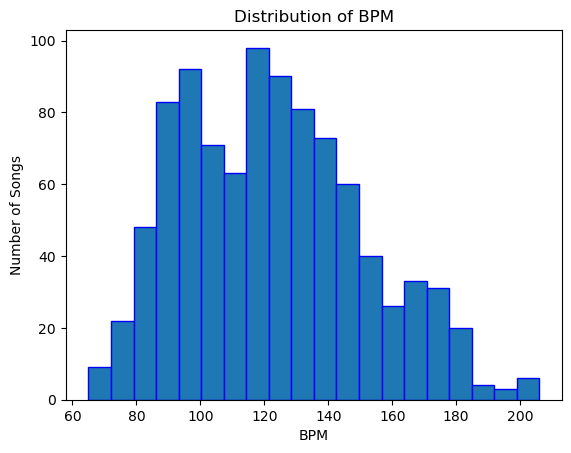

In [18]:
import matplotlib.pyplot as plt

plt.hist(df['bpm'], bins=20, edgecolor='blue')
plt.title('Distribution of BPM')
plt.xlabel('BPM')
plt.ylabel('Number of Songs')
plt.show()

In [21]:
print("Average BPM:", df['bpm'].mean())
print("Median BPM:", df['bpm'].median())
print("Most common BPM:", df['bpm'].mode()[0])

Average BPM: 122.54039874081847
Median BPM: 121.0
Most common BPM: 120


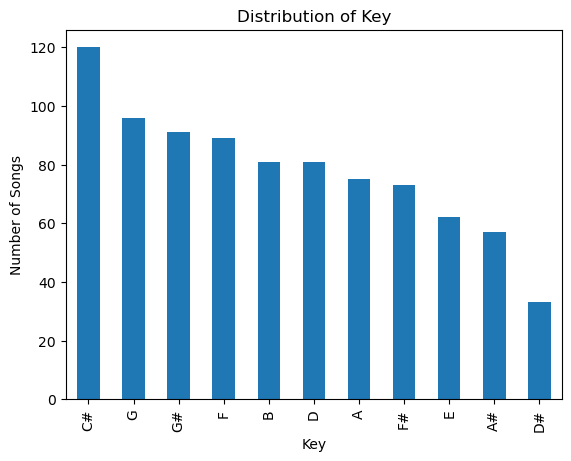

In [22]:
df['key'].value_counts().plot(kind='bar')

plt.title('Distribution of Key')
plt.xlabel('Key')
plt.ylabel('Number of Songs')
plt.show()

In [24]:
print(df['key'].value_counts())
print("Most common key:", df['key'].mode()[0])

key
C#    120
G      96
G#     91
F      89
B      81
D      81
A      75
F#     73
E      62
A#     57
D#     33
Name: count, dtype: int64
Most common key: C#


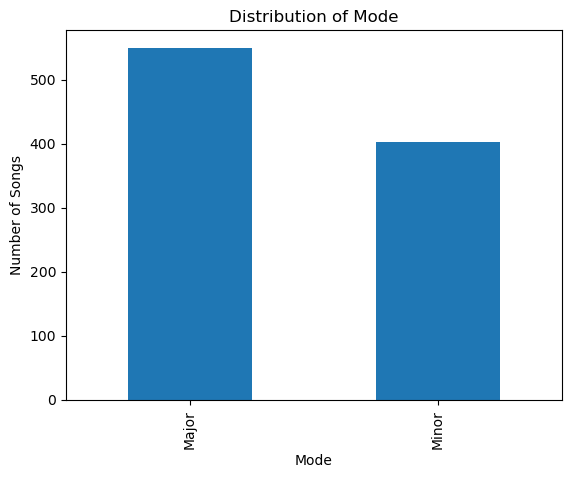

In [26]:
df['mode'].value_counts().plot(kind='bar')

plt.title('Distribution of Mode')
plt.xlabel('Mode')
plt.ylabel('Number of Songs')
plt.show()

In [25]:
print(df['mode'].value_counts())
print("Most common mode:", df['mode'].mode()[0])

mode
Major    550
Minor    403
Name: count, dtype: int64
Most common mode: Major


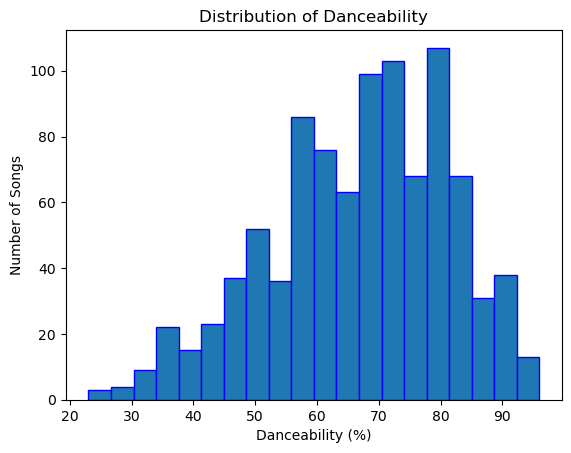

In [27]:
plt.hist(df['danceability_%'], bins=20, edgecolor='blue')

plt.title('Distribution of Danceability')
plt.xlabel('Danceability (%)')
plt.ylabel('Number of Songs')
plt.show()

In [28]:
print("Average Danceability:", df['danceability_%'].mean())
print("Median Danceability:", df['danceability_%'].median())
print("Most common Danceability:", df['danceability_%'].mode()[0])

Average Danceability: 66.96956977964324
Median Danceability: 69.0
Most common Danceability: 70


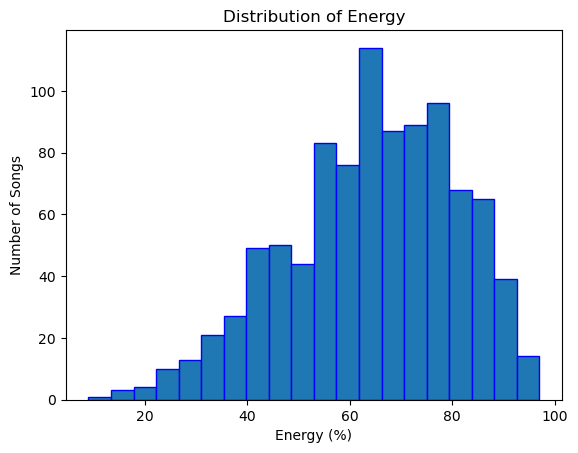

In [29]:
plt.hist(df['energy_%'], bins=20, edgecolor='blue')

plt.title('Distribution of Energy')
plt.xlabel('Energy (%)')
plt.ylabel('Number of Songs')
plt.show()

In [30]:
print("Average Energy:", df['energy_%'].mean())
print("Median Energy:", df['energy_%'].median())
print("Most common Energy:", df['energy_%'].mode()[0])

Average Energy: 64.2791185729276
Median Energy: 66.0
Most common Energy: 74


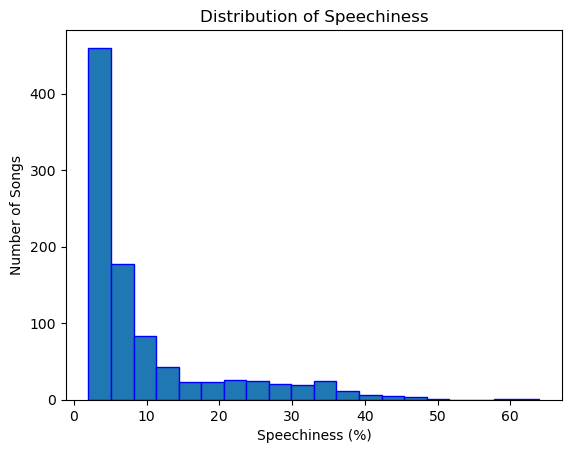

In [31]:
plt.hist(df['speechiness_%'], bins=20, edgecolor='blue')

plt.title('Distribution of Speechiness')
plt.xlabel('Speechiness (%)')
plt.ylabel('Number of Songs')
plt.show()

In [32]:
print("Average Speechiness:", df['speechiness_%'].mean())
print("Median Speechiness:", df['speechiness_%'].median())
print("Most common Speechiness:", df['speechiness_%'].mode()[0])

Average Speechiness: 10.131164742917104
Median Speechiness: 6.0
Most common Speechiness: 4


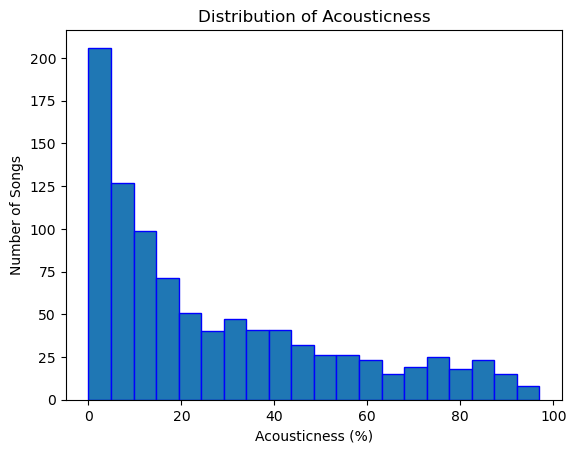

In [33]:
plt.hist(df['acousticness_%'], bins=20, edgecolor='blue')

plt.title('Distribution of Acousticness')
plt.xlabel('Acousticness (%)')
plt.ylabel('Number of Songs')
plt.show()

In [34]:
print("Average Acousticness:", df['acousticness_%'].mean())
print("Median Acousticness:", df['acousticness_%'].median())
print("Most common Acousticness:", df['acousticness_%'].mode()[0])

Average Acousticness: 27.057712486883524
Median Acousticness: 18.0
Most common Acousticness: 0


In [35]:
smash_hits = df[
    (df['bpm'].between(110, 130)) &
    (df['key'] == 'C#') &
    (df['mode'] == 'Major') &
    (df['danceability_%'].between(60, 80)) &
    (df['energy_%'].between(60, 80)) &
    (df['speechiness_%'].between(3, 10)) &
    (df['acousticness_%'].between(0, 30))
]

smash_hits

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
106,Cold Heart - PNAU Remix,"Dua Lipa, Elton John, Pnau",3,2017,11,10,21097,52,1605224506,384,...,116,C#,Major,80,92,80,4,0,10,3
107,Dandelions,Ruth B.,1,2017,4,28,3423,21,1116995633,41,...,117,C#,Major,61,45,69,2,0,9,3
168,We Found Love,"Rihanna, Calvin Harris",2,2011,1,1,36843,21,1235005533,321,...,128,C#,Major,73,60,77,3,0,11,4
236,AMERICA HAS A PROBLEM (feat. Kendrick Lamar),"Kendrick Lamar, Beyoncï¿",2,2023,5,19,896,0,57089066,34,...,126,C#,Major,78,20,70,1,0,16,4
518,Need To Know,Doja Cat,1,2021,6,11,6672,0,1042568408,125,...,130,C#,Major,66,19,61,30,0,9,7
660,Ginseng Strip 2002,Yung Lean,1,2013,8,16,4310,0,240769997,13,...,115,C#,Major,60,37,71,8,0,48,4


In [37]:
smash_hits[
    ['track_name', 'artist(s)_name', 'streams',
     'in_spotify_playlists', 'bpm', 'key', 'mode',
     'danceability_%', 'energy_%',
     'speechiness_%', 'acousticness_%']
    ]

,track_name,artist(s)_name,streams,in_spotify_playlists,bpm,key,mode,danceability_%,energy_%,speechiness_%,acousticness_%
106,Cold Heart - PNAU Remix,"Dua Lipa, Elton John, Pnau",1605224506,21097,116,C#,Major,80,80,3,4
107,Dandelions,Ruth B.,1116995633,3423,117,C#,Major,61,69,3,2
168,We Found Love,"Rihanna, Calvin Harris",1235005533,36843,128,C#,Major,73,77,4,3
236,AMERICA HAS A PROBLEM (feat. Kendrick Lamar),"Kendrick Lamar, Beyoncï¿",57089066,896,126,C#,Major,78,70,4,1
518,Need To Know,Doja Cat,1042568408,6672,130,C#,Major,66,61,7,30
660,Ginseng Strip 2002,Yung Lean,240769997,4310,115,C#,Major,60,71,4,8


In [40]:
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')

In [46]:
smash_hits = df[
    (df['bpm'].between(110, 130)) &
    (df['key'] == 'C#') &
    (df['mode'] == 'Major') &
    (df['danceability_%'].between(60, 80)) &
    (df['energy_%'].between(60, 80)) &
    (df['speechiness_%'].between(3, 10)) &
    (df['acousticness_%'].between(0, 30))
]

print("Median streams for all songs:", f"{df['streams'].median():,.0f}")

display(
    smash_hits[
        ['track_name', 'artist(s)_name', 'streams']
    ].reset_index(drop=True)
)

Median streams for all songs: 290,530,915


,track_name,artist(s)_name,streams
0,Cold Heart - PNAU Remix,"Dua Lipa, Elton John, Pnau",1.605225e+09
1,Dandelions,Ruth B.,1.116996e+09
2,We Found Love,"Rihanna, Calvin Harris",1.235006e+09
3,AMERICA HAS A PROBLEM (feat. Kendrick Lamar),"Kendrick Lamar, Beyoncï¿",5.708907e+07
4,Need To Know,Doja Cat,1.042568e+09
5,Ginseng Strip 2002,Yung Lean,2.407700e+08


In [47]:
hit = df[df['track_name'] == 'We Found Love']

hit[[
    'track_name', 'artist(s)_name', 'streams',
    'bpm', 'key', 'mode',
    'danceability_%', 'energy_%',
    'speechiness_%', 'acousticness_%'
]]

,track_name,artist(s)_name,streams,bpm,key,mode,danceability_%,energy_%,speechiness_%,acousticness_%
168,We Found Love,"Rihanna, Calvin Harris",1.235006e+09,128,C#,Major,73,77,4,3


In [48]:
comparison = pd.DataFrame({
    'Feature': ['BPM', 'Danceability', 'Energy', 'Speechiness', 'Acousticness'],
    
    'We Found Love': [
        hit['bpm'].iloc[0],
        hit['danceability_%'].iloc[0],
        hit['energy_%'].iloc[0],
        hit['speechiness_%'].iloc[0],
        hit['acousticness_%'].iloc[0]
    ],
    
    'Dataset Median': [
        df['bpm'].median(),
        df['danceability_%'].median(),
        df['energy_%'].median(),
        df['speechiness_%'].median(),
        df['acousticness_%'].median()
    ]
})

comparison

,Feature,We Found Love,Dataset Median
0,BPM,128,121.0
1,Danceability,73,69.0
2,Energy,77,66.0
3,Speechiness,4,6.0
4,Acousticness,3,18.0


In [ ]:
For my smash hit, I picked We Found Love by Rihanna and Calvin Harris. The song has a BPM of 128, while the dataset median was 121. It also has 73% danceability and 77% energy, which are both a little higher than the normal values in the dataset.

The song has 4% speechiness and only 3% acousticness. It is also in C# Major, which matches the most common key and mode that I found earlier.

Overall, We Found Love matches our smash hit formula pretty well.